### Section 2: Exploratory Analysis of the data set

##### Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_path = "/Users/sunsally/Desktop/Red-wine-quality-classification/data/winequality-red.csv"
df = pd.read_csv(file_path, sep=";", quotechar='"')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (1599, 12)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


##### Target variable(quality) distribution

Original quality score distribution:
3     10
4     53
5    681
6    638
7    199
8     18
Name: quality, dtype: int64


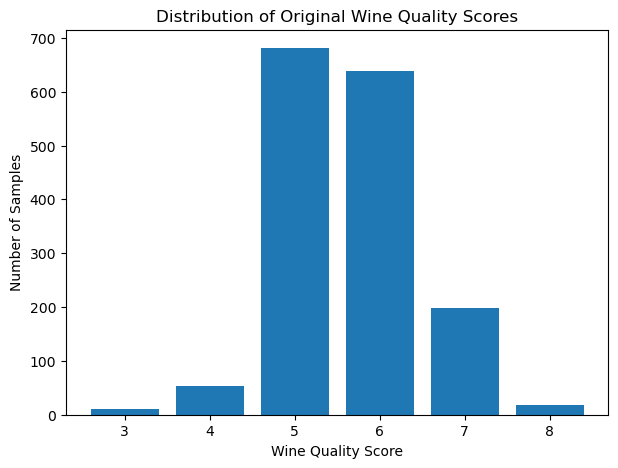

In [3]:
quality_counts = df['quality'].value_counts().sort_index()

print("Original quality score distribution:")
print(quality_counts)

plt.figure(figsize=(7,5))
plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Samples")
plt.title("Distribution of Original Wine Quality Scores")
plt.show()

##### Correlation with original quality

In [10]:
quality_corr = df.corr()['quality'].sort_values(ascending=False)

print("Correlation with wine quality:")
print(quality_corr)

Correlation with wine quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


##### Correlation heatmap

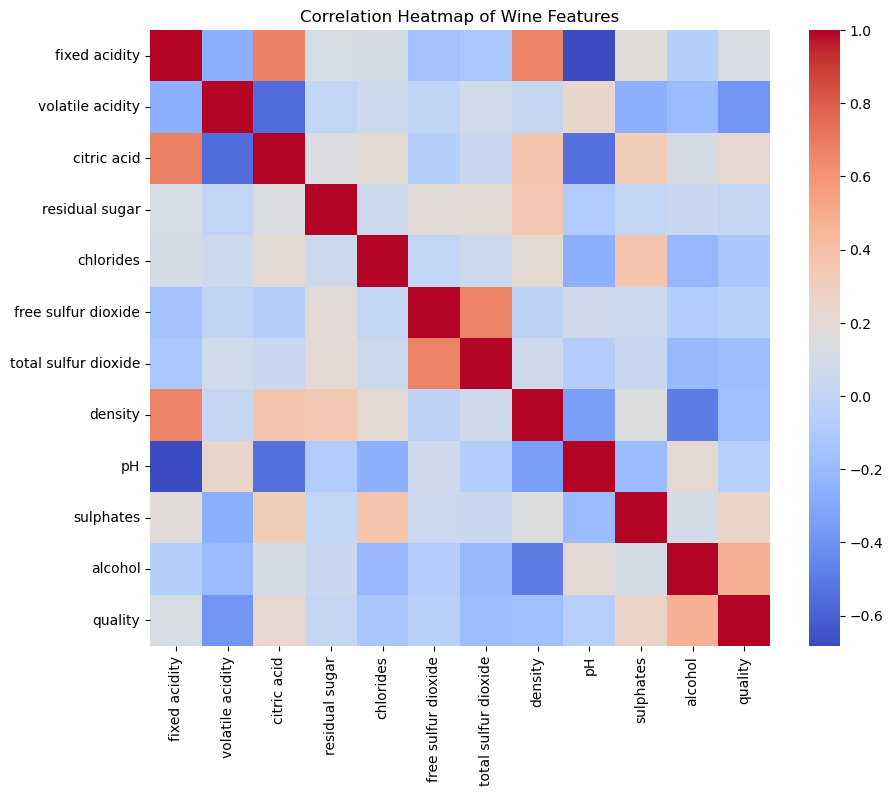

In [11]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Features")
plt.show()

##### Selected important features

Based on the correlation analysis, several variables show stronger relationships with wine quality. In particular, alcohol has the strongest positive correlation with quality, while volatile acidity shows a strong negative correlation. Sulphates and citric acid also exhibit moderate positive relationships.

Based on these observations, we select the following features for further analysis: alcohol, volatile acidity, sulphates, density, and total sulfur dioxide. These variables either show relatively strong correlations with the target variable or are chemically meaningful indicators of wine composition.

In [18]:
selected_features = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'density',
    'total sulfur dioxide',
]

##### Distributions for selected important variables

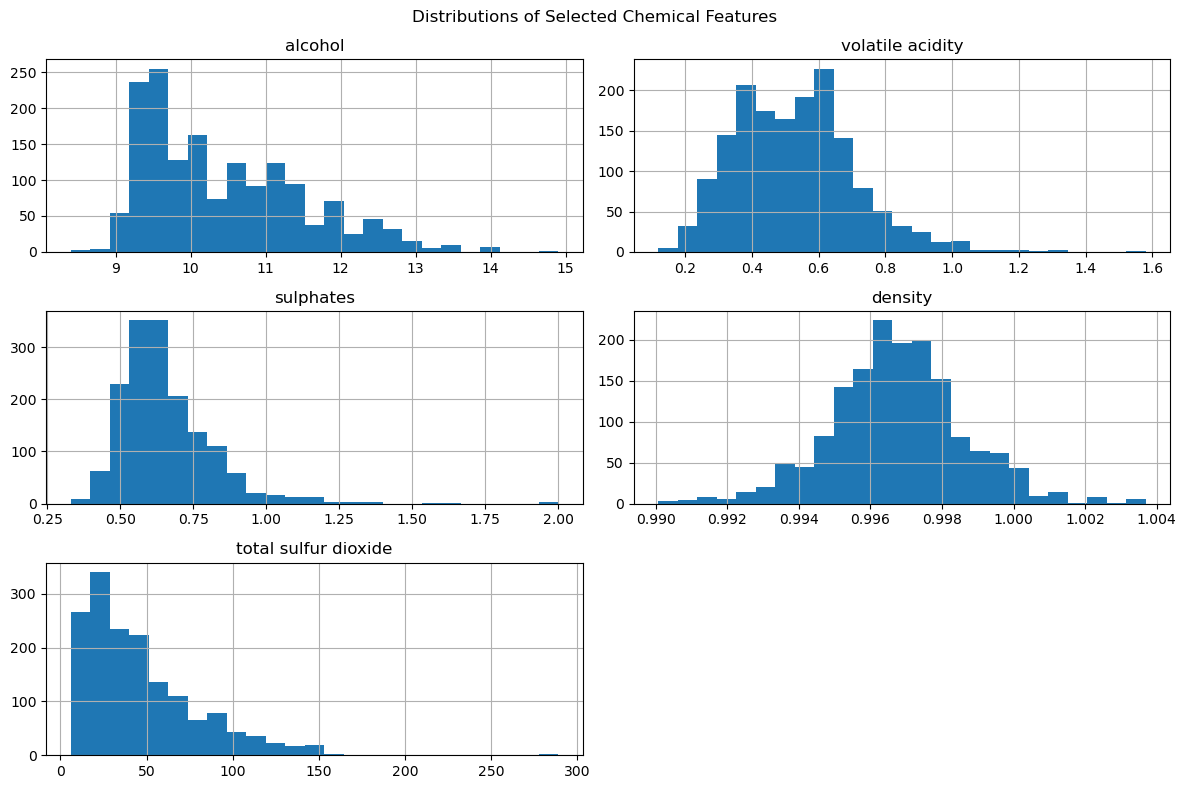

In [19]:
df[selected_features].hist(figsize=(12,8), bins=25)
plt.suptitle("Distributions of Selected Chemical Features")
plt.tight_layout()
plt.show()

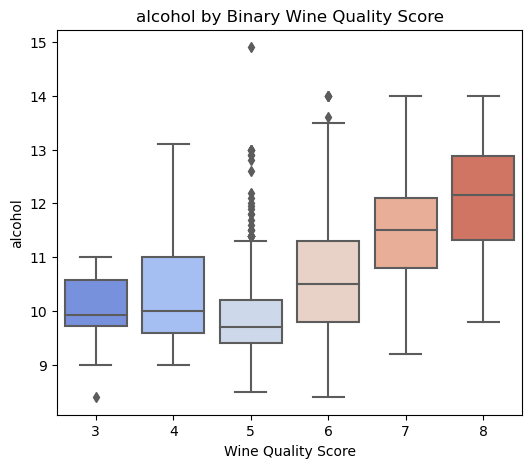

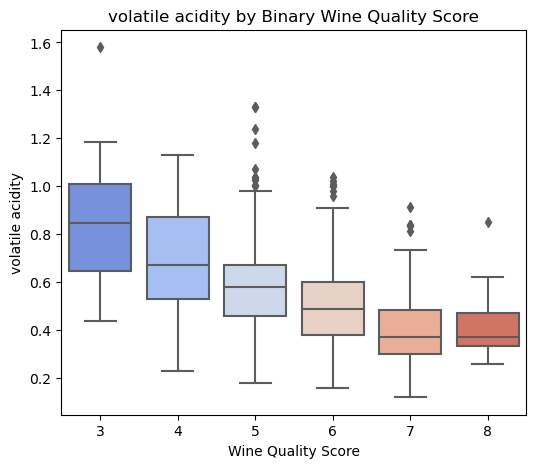

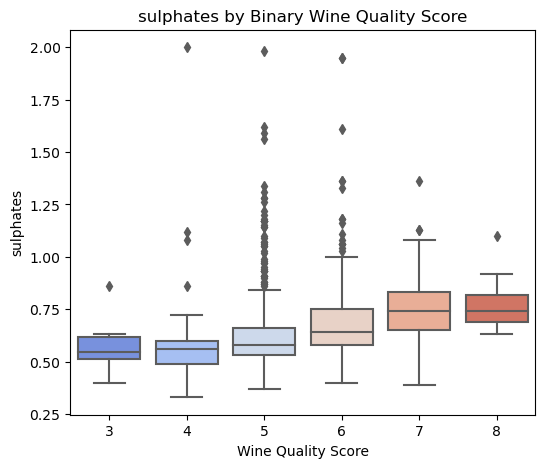

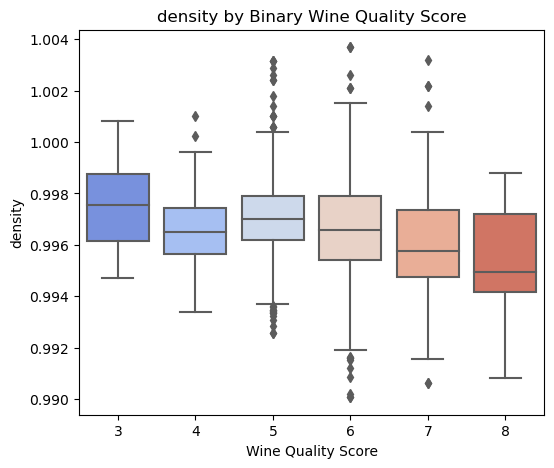

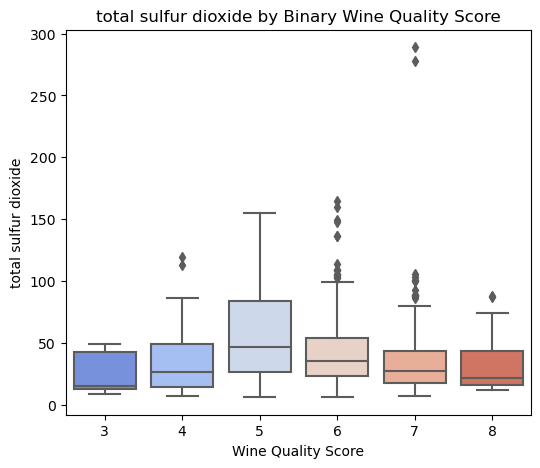

In [12]:
# Boxplots: important features vs binary quality
for feature in ['alcohol', 'volatile acidity', 'sulphates', 'density','total sulfur dioxide']:
    plt.figure(figsize=(6,5))
    sns.boxplot(x='quality', y=feature, data=df, palette="coolwarm")
    plt.xlabel("Wine Quality Score")
    plt.ylabel(feature)
    plt.title(f"{feature} by Binary Wine Quality Score")
    plt.show()